# HESPE Student Performance — PySpark ML Pipeline

## Clasificación multiclase, validación robusta y model selection con Spark ML

Este proyecto implementa un flujo reproducible de Machine Learning con **PySpark / Spark ML** para predecir el rendimiento académico final de estudiantes en el dataset **Higher Education Students Performance Evaluation (HESPE)**.

### Objetivos técnicos

- cargar datos mediante un **schema explícito**;
- auditar calidad, dominios, duplicados y distribución del target;
- realizar EDA con transformaciones agregadas en Spark;
- construir un `Pipeline` reproducible de preprocesamiento;
- comparar un baseline de **Logistic Regression multinomial** con un **Random Forest**;
- seleccionar hiperparámetros mediante `CrossValidator`;
- evaluar con Accuracy, Weighted F1, Macro F1, matriz de confusión y métricas ordinales;
- interpretar el Random Forest agregando feature importances a las variables originales.

> **Alcance:** el dataset contiene solo 145 observaciones. PySpark se usa aquí para demostrar una arquitectura y un pipeline escalables; **este notebook no constituye un benchmark de rendimiento Big Data**.

## 1. Fuente del dataset y formulación del problema

El dataset original fue publicado en UCI Machine Learning Repository:

- **Higher Education Students Performance Evaluation**
- 145 instancias
- 31 features
- tarea oficial: **Classification**
- licencia: **CC BY 4.0**
- DOI: `10.24432/C51G82`

La variable objetivo `grade` tiene ocho categorías ordenadas:

| Código | Categoría |
|---:|---|
| 0 | Fail |
| 1 | DD |
| 2 | DC |
| 3 | CC |
| 4 | CB |
| 5 | BB |
| 6 | BA |
| 7 | AA |

La entrega académica original trataba `grade` como regresión ordinal aproximada. Para esta versión de portafolio se utiliza **clasificación multiclase como formulación principal**, porque coincide con la definición oficial del dataset y permite evaluar explícitamente errores por clase mediante matriz de confusión.

La naturaleza ordinal no se ignora: se añaden **MAE ordinal**, exactitud dentro de ±1 categoría y exactitud dentro de ±2 categorías.

## 2. Setup de Spark y reproducibilidad

Para ejecución local / CI se utiliza Spark en modo `local[*]`. En un clúster real puede definirse `SPARK_MASTER` como variable de entorno sin modificar el notebook.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

SEED = 42
TEST_FRACTION = 0.20

random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = Path("data/hespe-data.csv")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

builder = (
    SparkSession.builder
    .appName("HESPE_PySpark_Portfolio")
    .config("spark.sql.shuffle.partitions", "8")
)

spark = builder.master(os.getenv("SPARK_MASTER", "local[*]")).getOrCreate()
spark.sparkContext.setLogLevel("WARN")

print("Spark:", spark.version)
print("Master:", spark.sparkContext.master)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/10/01 18:59:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 4.0.1
Master: local[*]


## 3. Carga con schema explícito

En el notebook original se utilizaba `inferSchema=True`. En un flujo orientado a grandes volúmenes esto obliga a Spark a inspeccionar el archivo y puede producir inferencias inconsistentes entre fuentes.

Aquí se declara el schema de forma explícita: `student_id` es string y las demás columnas son enteros codificados.

In [2]:
COLUMNS = [
    "student_id",
    "age",
    "sex",
    "graduated_h_school_type",
    "scholarship_type",
    "additional_work",
    "activity",
    "partner",
    "total_salary",
    "transport",
    "accomodation",
    "mother_ed",
    "farther_ed",
    "siblings",
    "parental_status",
    "mother_occup",
    "father_occup",
    "weekly_study_hours",
    "reading_non_scientific",
    "reading_scientific",
    "attendance_seminars_dep",
    "impact_of_projects",
    "attendances_classes",
    "preparation_midterm_company",
    "preparation_midterm_time",
    "taking_notes",
    "listenning",
    "discussion_improves_interest",
    "flip_classrom",
    "grade_previous",
    "grade_expected",
    "course_id",
    "grade",
]

schema = StructType(
    [StructField("student_id", StringType(), nullable=False)]
    + [StructField(c, IntegerType(), nullable=True) for c in COLUMNS[1:]]
)

assert DATA_PATH.exists(), f"No se encontró {DATA_PATH}"

df = (
    spark.read
    .option("header", True)
    .option("sep", ";")
    .schema(schema)
    .csv(str(DATA_PATH))
    .cache()
)

n_rows = df.count()
print("Filas:", n_rows)
print("Columnas:", len(df.columns))
df.printSchema()
df.show(5, truncate=False)

26/10/01 18:59:08 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Filas: 145
Columnas: 33
root
 |-- student_id: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- sex: integer (nullable = true)
 |-- graduated_h_school_type: integer (nullable = true)
 |-- scholarship_type: integer (nullable = true)
 |-- additional_work: integer (nullable = true)
 |-- activity: integer (nullable = true)
 |-- partner: integer (nullable = true)
 |-- total_salary: integer (nullable = true)
 |-- transport: integer (nullable = true)
 |-- accomodation: integer (nullable = true)
 |-- mother_ed: integer (nullable = true)
 |-- farther_ed: integer (nullable = true)
 |-- siblings: integer (nullable = true)
 |-- parental_status: integer (nullable = true)
 |-- mother_occup: integer (nullable = true)
 |-- father_occup: integer (nullable = true)
 |-- weekly_study_hours: integer (nullable = true)
 |-- reading_non_scientific: integer (nullable = true)
 |-- reading_scientific: integer (nullable = true)
 |-- attendance_seminars_dep: integer (nullable = true)
 |-- impact_of

+----------+---+---+-----------------------+----------------+---------------+--------+-------+------------+---------+------------+---------+----------+--------+---------------+------------+------------+------------------+----------------------+------------------+-----------------------+------------------+-------------------+---------------------------+------------------------+------------+----------+----------------------------+-------------+--------------+--------------+---------+-----+
|student_id|age|sex|graduated_h_school_type|scholarship_type|additional_work|activity|partner|total_salary|transport|accomodation|mother_ed|farther_ed|siblings|parental_status|mother_occup|father_occup|weekly_study_hours|reading_non_scientific|reading_scientific|attendance_seminars_dep|impact_of_projects|attendances_classes|preparation_midterm_company|preparation_midterm_time|taking_notes|listenning|discussion_improves_interest|flip_classrom|grade_previous|grade_expected|course_id|grade|
+----------+--

## 4. Auditoría de calidad de datos

Se revisan nulos, duplicados, cardinalidad y dominios esperados. Los rangos corresponden a la codificación documentada por UCI; no se interpretan como magnitudes continuas salvo cuando existe un orden natural.

In [3]:
# Nulos en una sola agregación
null_exprs = [
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
]
nulls = df.agg(*null_exprs)
nulls.show(truncate=False)

duplicate_count = df.count() - df.dropDuplicates().count()
student_id_unique = df.select(F.countDistinct("student_id").alias("n")).first()["n"]
course_id_unique = df.select(F.countDistinct("course_id").alias("n")).first()["n"]

print("Duplicados completos:", duplicate_count)
print("student_id únicos:", student_id_unique, "/", n_rows)
print("course_id únicos:", course_id_unique)

+----------+---+---+-----------------------+----------------+---------------+--------+-------+------------+---------+------------+---------+----------+--------+---------------+------------+------------+------------------+----------------------+------------------+-----------------------+------------------+-------------------+---------------------------+------------------------+------------+----------+----------------------------+-------------+--------------+--------------+---------+-----+
|student_id|age|sex|graduated_h_school_type|scholarship_type|additional_work|activity|partner|total_salary|transport|accomodation|mother_ed|farther_ed|siblings|parental_status|mother_occup|father_occup|weekly_study_hours|reading_non_scientific|reading_scientific|attendance_seminars_dep|impact_of_projects|attendances_classes|preparation_midterm_company|preparation_midterm_time|taking_notes|listenning|discussion_improves_interest|flip_classrom|grade_previous|grade_expected|course_id|grade|
+----------+--

Duplicados completos: 0
student_id únicos: 145 / 145
course_id únicos: 9


In [4]:
EXPECTED_RANGES = {
    "age": (1, 3),
    "sex": (1, 2),
    "graduated_h_school_type": (1, 3),
    "scholarship_type": (1, 5),
    "additional_work": (1, 2),
    "activity": (1, 2),
    "partner": (1, 2),
    "total_salary": (1, 5),
    "transport": (1, 4),
    "accomodation": (1, 4),
    "mother_ed": (1, 6),
    "farther_ed": (1, 6),
    "siblings": (1, 5),
    "parental_status": (1, 3),
    "mother_occup": (1, 6),
    "father_occup": (1, 5),
    "weekly_study_hours": (1, 5),
    "reading_non_scientific": (1, 3),
    "reading_scientific": (1, 3),
    "attendance_seminars_dep": (1, 2),
    "impact_of_projects": (1, 3),
    "attendances_classes": (1, 3),
    "preparation_midterm_company": (1, 3),
    "preparation_midterm_time": (1, 3),
    "taking_notes": (1, 3),
    "listenning": (1, 3),
    "discussion_improves_interest": (1, 3),
    "flip_classrom": (1, 3),
    "grade_previous": (1, 5),
    "grade_expected": (1, 5),
    "grade": (0, 7),
}

violation_exprs = []
for c, (low, high) in EXPECTED_RANGES.items():
    violation_exprs.append(
        F.sum(
            F.when(
                F.col(c).isNull() | (F.col(c) < low) | (F.col(c) > high),
                1,
            ).otherwise(0)
        ).alias(c)
    )

range_violations = df.agg(*violation_exprs)
range_violations.show(truncate=False)

+---+---+-----------------------+----------------+---------------+--------+-------+------------+---------+------------+---------+----------+--------+---------------+------------+------------+------------------+----------------------+------------------+-----------------------+------------------+-------------------+---------------------------+------------------------+------------+----------+----------------------------+-------------+--------------+--------------+-----+
|age|sex|graduated_h_school_type|scholarship_type|additional_work|activity|partner|total_salary|transport|accomodation|mother_ed|farther_ed|siblings|parental_status|mother_occup|father_occup|weekly_study_hours|reading_non_scientific|reading_scientific|attendance_seminars_dep|impact_of_projects|attendances_classes|preparation_midterm_company|preparation_midterm_time|taking_notes|listenning|discussion_improves_interest|flip_classrom|grade_previous|grade_expected|grade|
+---+---+-----------------------+----------------+------

### Decisión sobre identificadores

- `student_id` tiene una cardinalidad igual al número de filas y es un identificador de registro: **se excluye**.
- `course_id` **no es un identificador de fila**: tiene solo nueve valores y UCI lo define como feature. Sin embargo, las distribuciones de notas cambian mucho entre cursos. Como el escenario del caso plantea extender el análisis a nuevas instituciones, el modelo principal lo excluye para reducir dependencia de contexto específico de curso.

Esta es una decisión de generalización, no la afirmación de que `course_id` “no tenga poder predictivo”. En un sistema real se debería comparar explícitamente validación in-domain vs. validación por curso/institución.

## 5. EDA distribuido

En un proyecto Spark no conviene convertir todo el dataset crudo a pandas. Las visualizaciones se construyen después de **agregar en Spark** y solo entonces recolectar tablas pequeñas para graficar.

+-----+-----+-------------------+
|grade|count|                pct|
+-----+-----+-------------------+
|    0|    8|0.05517241379310345|
|    1|   35| 0.2413793103448276|
|    2|   24|0.16551724137931034|
|    3|   21|0.14482758620689656|
|    4|   10|0.06896551724137931|
|    5|   17|0.11724137931034483|
|    6|   13| 0.0896551724137931|
|    7|   17|0.11724137931034483|
+-----+-----+-------------------+



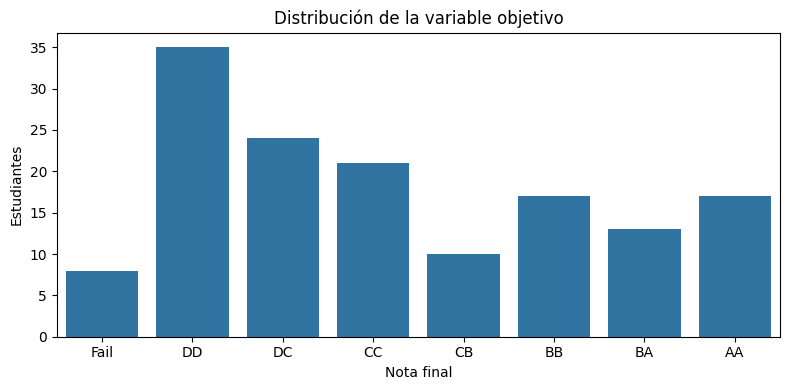

In [5]:
GRADE_LABELS = {
    0: "Fail",
    1: "DD",
    2: "DC",
    3: "CC",
    4: "CB",
    5: "BB",
    6: "BA",
    7: "AA",
}

target_dist = (
    df.groupBy("grade")
    .count()
    .withColumn("pct", F.col("count") / F.lit(n_rows))
    .orderBy("grade")
)

target_dist.show()

target_pd = target_dist.toPandas()
target_pd["label"] = target_pd["grade"].map(GRADE_LABELS)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=target_pd, x="label", y="count", ax=ax)
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Nota final")
ax.set_ylabel("Estudiantes")
fig.tight_layout()
fig.savefig(FIG_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

In [6]:
# Estadísticas compactas para variables ordinales académicamente relevantes
eda_numeric = [
    "age",
    "weekly_study_hours",
    "siblings",
    "grade_previous",
    "grade_expected",
]
df.select(*eda_numeric).summary("count", "mean", "stddev", "min", "max").show()

+-------+------------------+------------------+------------------+------------------+------------------+
|summary|               age|weekly_study_hours|          siblings|    grade_previous|    grade_expected|
+-------+------------------+------------------+------------------+------------------+------------------+
|  count|               145|               145|               145|               145|               145|
|   mean|1.6206896551724137|               2.2| 2.806896551724138|3.1241379310344826|2.7241379310344827|
| stddev|0.6131540217646216|0.9174239296348591|1.3606399215694736|  1.30108266146084| 0.916536040849592|
|    min|                 1|                 1|                 1|                 1|                 1|
|    max|                 3|                 5|                 5|                 5|                 4|
+-------+------------------+------------------+------------------+------------------+------------------+



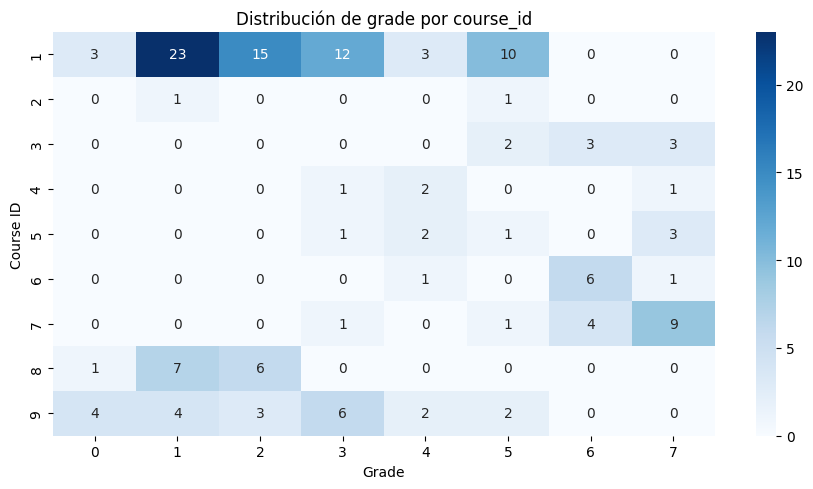

In [7]:
# Course ID no es un ID de fila: auditamos su asociación descriptiva con grade.
course_grade = (
    df.groupBy("course_id", "grade")
    .count()
    .orderBy("course_id", "grade")
)

course_grade_pd = course_grade.toPandas()
course_pivot = (
    course_grade_pd.pivot(index="course_id", columns="grade", values="count")
    .fillna(0)
    .reindex(columns=range(8), fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(course_pivot, annot=True, fmt=".0f", cmap="Blues", ax=ax)
ax.set_title("Distribución de grade por course_id")
ax.set_xlabel("Grade")
ax.set_ylabel("Course ID")
fig.tight_layout()
fig.savefig(FIG_DIR / "course_grade_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

In [8]:
# Correlaciones descriptivas sobre variables con orden natural.
ordered_features_for_corr = [
    "age",
    "scholarship_type",
    "total_salary",
    "mother_ed",
    "farther_ed",
    "siblings",
    "weekly_study_hours",
    "reading_non_scientific",
    "reading_scientific",
    "attendances_classes",
    "taking_notes",
    "listenning",
    "discussion_improves_interest",
    "grade_previous",
    "grade_expected",
]

corr_rows = []
for feature in ordered_features_for_corr:
    corr_rows.append({
        "feature": feature,
        "corr_with_grade": df.stat.corr(feature, "grade"),
    })

corr_pd = (
    pd.DataFrame(corr_rows)
    .sort_values("corr_with_grade", key=lambda s: s.abs(), ascending=False)
)
display(corr_pd)

,feature,corr_with_grade
13,grade_previous,0.315493
14,grade_expected,0.248588
7,reading_non_scientific,0.195617
2,total_salary,-0.166352
12,discussion_improves_interest,0.146547
9,attendances_classes,-0.139564
0,age,-0.095251
11,listenning,0.085137
5,siblings,0.084470
3,mother_ed,0.066318


## 6. Preparación de features

La codificación original usa números para representar categorías. No se debe asumir que todos esos códigos son variables continuas.

### Ordinales
Se conservan como valores ordenados cuando la documentación define un orden natural.

### Nominales
Se procesan con `StringIndexer` + `OneHotEncoder`.

Para Random Forest **no se aplica escalamiento**, porque los árboles no lo necesitan. Para Logistic Regression se escala solo el bloque ordinal y se usa `withMean=False`, evitando densificar innecesariamente las representaciones sparse de OHE.

In [9]:
TARGET_COL = "grade"

ORDINAL_COLS = [
    "age",
    "scholarship_type",
    "total_salary",
    "mother_ed",
    "farther_ed",
    "siblings",
    "weekly_study_hours",
    "reading_non_scientific",
    "reading_scientific",
    "attendances_classes",
    "taking_notes",
    "listenning",
    "discussion_improves_interest",
    "grade_previous",
    "grade_expected",
]

NOMINAL_COLS = [
    "sex",
    "graduated_h_school_type",
    "additional_work",
    "activity",
    "partner",
    "transport",
    "accomodation",
    "parental_status",
    "mother_occup",
    "father_occup",
    "attendance_seminars_dep",
    "impact_of_projects",
    "preparation_midterm_company",
    "preparation_midterm_time",
    "flip_classrom",
]

MODEL_COLS = ORDINAL_COLS + NOMINAL_COLS + [TARGET_COL]
df_model = df.select(*MODEL_COLS)

print("Ordinales:", len(ORDINAL_COLS))
print("Nominales:", len(NOMINAL_COLS))
print("Features del modelo principal:", len(ORDINAL_COLS) + len(NOMINAL_COLS))

Ordinales: 15
Nominales: 15
Features del modelo principal: 30


## 7. Split estratificado train/test

`randomSplit` no garantiza representación de las ocho clases en conjuntos pequeños. Se implementa un split estratificado determinista por `grade`, reservando aproximadamente 20% de cada clase para test.

In [10]:
def stratified_train_test_split(
    dataframe,
    label_col,
    test_fraction=0.20,
    seed=42,
):
    counts = (
        dataframe.groupBy(label_col)
        .count()
        .withColumn(
            "_n_test",
            F.least(
                F.col("count") - F.lit(1),
                F.greatest(
                    F.lit(1),
                    F.round(F.col("count") * F.lit(test_fraction)).cast("int"),
                ),
            ),
        )
    )

    w = Window.partitionBy(label_col).orderBy(F.rand(seed))

    ranked = (
        dataframe
        .withColumn("_row_number", F.row_number().over(w))
        .join(counts.select(label_col, "_n_test"), on=label_col, how="left")
    )

    test = (
        ranked
        .filter(F.col("_row_number") <= F.col("_n_test"))
        .drop("_row_number", "_n_test")
    )

    train = (
        ranked
        .filter(F.col("_row_number") > F.col("_n_test"))
        .drop("_row_number", "_n_test")
    )

    return train, test


train_df, test_df = stratified_train_test_split(
    df_model,
    TARGET_COL,
    test_fraction=TEST_FRACTION,
    seed=SEED,
)

train_df = train_df.cache()
test_df = test_df.cache()

print("Train:", train_df.count())
print("Test:", test_df.count())

print("Distribución train")
train_df.groupBy(TARGET_COL).count().orderBy(TARGET_COL).show()

print("Distribución test")
test_df.groupBy(TARGET_COL).count().orderBy(TARGET_COL).show()

Train: 116


Test: 29
Distribución train
+-----+-----+
|grade|count|
+-----+-----+
|    0|    6|
|    1|   28|
|    2|   19|
|    3|   17|
|    4|    8|
|    5|   14|
|    6|   10|
|    7|   14|
+-----+-----+

Distribución test


+-----+-----+
|grade|count|
+-----+-----+
|    0|    2|
|    1|    7|
|    2|    5|
|    3|    4|
|    4|    2|
|    5|    3|
|    6|    3|
|    7|    3|
+-----+-----+



## 8. Construcción de pipelines

Se crean pipelines independientes para:

1. **Logistic Regression multinomial**: baseline lineal.
2. **Random Forest Classifier**: modelo no lineal principal.

El pipeline completo se entrega a `CrossValidator`, de modo que indexación, OHE y ensamblado se reajustan dentro de cada fold y no existe leakage desde validación hacia entrenamiento.

In [11]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler,
)
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier


def categorical_stages():
    indexers = [
        StringIndexer(
            inputCol=c,
            outputCol=f"{c}_idx",
            handleInvalid="keep",
        )
        for c in NOMINAL_COLS
    ]

    encoder = OneHotEncoder(
        inputCols=[f"{c}_idx" for c in NOMINAL_COLS],
        outputCols=[f"{c}_ohe" for c in NOMINAL_COLS],
        handleInvalid="keep",
        dropLast=True,
    )

    return indexers, encoder


# Baseline lineal
lr_indexers, lr_encoder = categorical_stages()

ordinal_assembler = VectorAssembler(
    inputCols=ORDINAL_COLS,
    outputCol="ordinal_vec",
)

ordinal_scaler = StandardScaler(
    inputCol="ordinal_vec",
    outputCol="ordinal_scaled",
    withMean=False,
    withStd=True,
)

lr_feature_assembler = VectorAssembler(
    inputCols=["ordinal_scaled"] + [f"{c}_ohe" for c in NOMINAL_COLS],
    outputCol="features",
)

lr = LogisticRegression(
    featuresCol="features",
    labelCol=TARGET_COL,
    family="multinomial",
    maxIter=300,
    regParam=0.05,
    elasticNetParam=0.0,
)

lr_pipeline = Pipeline(
    stages=[
        *lr_indexers,
        lr_encoder,
        ordinal_assembler,
        ordinal_scaler,
        lr_feature_assembler,
        lr,
    ]
)


# Random Forest: no scaling
rf_indexers, rf_encoder = categorical_stages()

rf_feature_assembler = VectorAssembler(
    inputCols=ORDINAL_COLS + [f"{c}_ohe" for c in NOMINAL_COLS],
    outputCol="features",
)

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=TARGET_COL,
    seed=SEED,
)

rf_pipeline = Pipeline(
    stages=[
        *rf_indexers,
        rf_encoder,
        rf_feature_assembler,
        rf,
    ]
)

## 9. Métricas multiclase + métricas ordinales

La rúbrica solicita matriz de confusión y análisis de falsos positivos/negativos. Para ocho clases, se reportan:

- Accuracy
- Weighted F1
- Weighted Precision
- Weighted Recall
- **Macro F1** calculado desde la matriz de confusión
- métricas por clase
- MAE ordinal
- exactitud dentro de ±1 y ±2 categorías

Las últimas tres métricas aprovechan que las clases tienen orden natural.

In [12]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator


def evaluate_multiclass(predictions, label_col=TARGET_COL, pred_col="prediction"):
    evaluators = {
        "accuracy": MulticlassClassificationEvaluator(
            labelCol=label_col, predictionCol=pred_col, metricName="accuracy"
        ),
        "weighted_f1": MulticlassClassificationEvaluator(
            labelCol=label_col, predictionCol=pred_col, metricName="f1"
        ),
        "weighted_precision": MulticlassClassificationEvaluator(
            labelCol=label_col, predictionCol=pred_col, metricName="weightedPrecision"
        ),
        "weighted_recall": MulticlassClassificationEvaluator(
            labelCol=label_col, predictionCol=pred_col, metricName="weightedRecall"
        ),
    }

    metrics = {name: evaluator.evaluate(predictions) for name, evaluator in evaluators.items()}

    cm_long = (
        predictions
        .select(
            F.col(label_col).cast("int").alias("actual"),
            F.col(pred_col).cast("int").alias("predicted"),
        )
        .groupBy("actual", "predicted")
        .count()
    )

    cm_pd = cm_long.toPandas()
    classes = list(range(8))
    cm = np.zeros((8, 8), dtype=int)

    for row in cm_pd.itertuples(index=False):
        cm[int(row.actual), int(row.predicted)] = int(row.count)

    per_class = []
    for i in classes:
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        support = cm[i, :].sum()

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall)
            else 0.0
        )

        per_class.append({
            "grade": i,
            "label": GRADE_LABELS[i],
            "support": int(support),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "false_negatives": int(fn),
            "false_positives": int(fp),
        })

    per_class_pd = pd.DataFrame(per_class)
    metrics["macro_f1"] = float(per_class_pd["f1"].mean())

    ordinal_row = (
        predictions
        .select(
            F.avg(F.abs(F.col(pred_col) - F.col(label_col))).alias("ordinal_mae"),
            F.avg(
                (F.abs(F.col(pred_col) - F.col(label_col)) <= 1)
                .cast("double")
            ).alias("within_1"),
            F.avg(
                (F.abs(F.col(pred_col) - F.col(label_col)) <= 2)
                .cast("double")
            ).alias("within_2"),
        )
        .first()
    )

    metrics["ordinal_mae"] = float(ordinal_row["ordinal_mae"])
    metrics["within_1"] = float(ordinal_row["within_1"])
    metrics["within_2"] = float(ordinal_row["within_2"])

    return metrics, cm, per_class_pd

## 10. Baseline — Logistic Regression multinomial

In [13]:
lr_model = lr_pipeline.fit(train_df)
lr_preds = lr_model.transform(test_df)

lr_metrics, lr_cm, lr_per_class = evaluate_multiclass(lr_preds)

display(pd.DataFrame([{"model": "Logistic Regression", **lr_metrics}]).round(4))
display(lr_per_class.round(4))

26/10/01 18:59:25 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


,model,accuracy,weighted_f1,weighted_precision,weighted_recall,macro_f1,ordinal_mae,within_1,within_2
0,Logistic Regression,0.2069,0.1879,0.1833,0.2069,0.1461,2.069,0.4828,0.6552


,grade,label,support,precision,recall,f1,false_negatives,false_positives
0,0,Fail,2,0.0000,0.0000,0.0000,2,0
1,1,DD,7,0.3333,0.4286,0.3750,4,6
2,2,DC,5,0.2500,0.2000,0.2222,4,3
3,3,CC,4,0.3333,0.2500,0.2857,3,2
4,4,CB,2,0.2000,0.5000,0.2857,1,4
5,5,BB,3,0.0000,0.0000,0.0000,3,3
6,6,BA,3,0.0000,0.0000,0.0000,3,1
7,7,AA,3,0.0000,0.0000,0.0000,3,4


## 11. Random Forest + CrossValidator + tuning

Se optimiza el Random Forest usando **Weighted F1** como métrica principal de selección. Se usa 3-fold CV porque el dataset es pequeño y la clase minoritaria tiene pocas observaciones.

In [14]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

rf_evaluator = MulticlassClassificationEvaluator(
    labelCol=TARGET_COL,
    predictionCol="prediction",
    metricName="f1",
)

param_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [100, 200])
    .addGrid(rf.maxDepth, [4, 8])
    .addGrid(rf.minInstancesPerNode, [1, 2])
    .build()
)

print("Configuraciones RF:", len(param_grid))

cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=param_grid,
    evaluator=rf_evaluator,
    numFolds=3,
    seed=SEED,
    parallelism=2,
    collectSubModels=False,
)

cv_model = cv.fit(train_df)

Configuraciones RF: 8


26/10/01 18:59:47 WARN DAGScheduler: Broadcasting large task binary with size 1189.1 KiB


26/10/01 18:59:47 WARN DAGScheduler: Broadcasting large task binary with size 1371.3 KiB


26/10/01 18:59:48 WARN DAGScheduler: Broadcasting large task binary with size 1085.2 KiB


26/10/01 18:59:49 WARN DAGScheduler: Broadcasting large task binary with size 1196.6 KiB


...

26/10/01 19:00:56 WARN DAGScheduler: Broadcasting large task binary with size 1802.0 KiB
26/10/01 19:00:56 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


26/10/01 19:00:56 WARN DAGScheduler: Broadcasting large task binary with size 1852.9 KiB


26/10/01 19:00:58 WARN DAGScheduler: Broadcasting large task binary with size 1677.9 KiB


26/10/01 19:01:01 WARN DAGScheduler: Broadcasting large task binary with size 1079.7 KiB
26/10/01 19:01:01 WARN DAGScheduler: Broadcasting large task binary with size 1392.6 KiB


26/10/01 19:01:01 WARN DAGScheduler: Broadcasting large task binary with size 1690.7 KiB


In [15]:
cv_rows = []

for param_map, score in zip(cv_model.getEstimatorParamMaps(), cv_model.avgMetrics):
    row = {"weighted_f1_cv": float(score)}
    for param, value in param_map.items():
        if param.name in {"numTrees", "maxDepth", "minInstancesPerNode"}:
            row[param.name] = value
    cv_rows.append(row)

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values("weighted_f1_cv", ascending=False)
    .reset_index(drop=True)
)

display(cv_results.round(4))

,weighted_f1_cv,numTrees,maxDepth,minInstancesPerNode
0,0.1739,100,8,1
1,0.1469,100,8,2
2,0.1289,200,8,2
3,0.1201,100,4,1
4,0.1129,200,4,2
5,0.1127,200,4,1
6,0.1007,200,8,1
7,0.0975,100,4,2


In [16]:
best_rf_pipeline = cv_model.bestModel
best_rf_stage = best_rf_pipeline.stages[-1]

best_params = {
    param.name: value
    for param, value in best_rf_stage.extractParamMap().items()
    if param.name in {
        "numTrees",
        "maxDepth",
        "minInstancesPerNode",
        "featureSubsetStrategy",
        "impurity",
    }
}

print("Mejor configuración RF:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

rf_preds = best_rf_pipeline.transform(test_df)
rf_metrics, rf_cm, rf_per_class = evaluate_multiclass(rf_preds)

display(pd.DataFrame([{"model": "Random Forest", **rf_metrics}]).round(4))
display(rf_per_class.round(4))

Mejor configuración RF:
  featureSubsetStrategy: auto
  impurity: gini
  maxDepth: 8
  minInstancesPerNode: 1
  numTrees: 100


26/10/01 19:01:02 WARN DAGScheduler: Broadcasting large task binary with size 1503.5 KiB


26/10/01 19:01:03 WARN DAGScheduler: Broadcasting large task binary with size 1503.5 KiB


26/10/01 19:01:03 WARN DAGScheduler: Broadcasting large task binary with size 1503.5 KiB


26/10/01 19:01:03 WARN DAGScheduler: Broadcasting large task binary with size 1503.5 KiB


26/10/01 19:01:03 WARN DAGScheduler: Broadcasting large task binary with size 1505.1 KiB


26/10/01 19:01:04 WARN DAGScheduler: Broadcasting large task binary with size 1453.4 KiB


,model,accuracy,weighted_f1,weighted_precision,weighted_recall,macro_f1,ordinal_mae,within_1,within_2
0,Random Forest,0.3793,0.3477,0.3326,0.3793,0.2986,1.7586,0.6207,0.7586


,grade,label,support,precision,recall,f1,false_negatives,false_positives
0,0,Fail,2,0.5000,0.5000,0.5000,1,1
1,1,DD,7,0.3636,0.5714,0.4444,3,7
2,2,DC,5,0.5000,0.4000,0.4444,3,2
3,3,CC,4,0.7500,0.7500,0.7500,1,1
4,4,CB,2,0.0000,0.0000,0.0000,2,0
5,5,BB,3,0.0000,0.0000,0.0000,3,2
6,6,BA,3,0.0000,0.0000,0.0000,3,1
7,7,AA,3,0.2000,0.3333,0.2500,2,4


## 12. Comparación de modelos

In [17]:
comparison = pd.DataFrame([
    {"model": "Logistic Regression", **lr_metrics},
    {"model": "Random Forest tuned", **rf_metrics},
])

display(
    comparison[
        [
            "model",
            "accuracy",
            "weighted_f1",
            "macro_f1",
            "weighted_precision",
            "weighted_recall",
            "ordinal_mae",
            "within_1",
            "within_2",
        ]
    ].round(4)
)

,model,accuracy,weighted_f1,macro_f1,weighted_precision,weighted_recall,ordinal_mae,within_1,within_2
0,Logistic Regression,0.2069,0.1879,0.1461,0.1833,0.2069,2.0690,0.4828,0.6552
1,Random Forest tuned,0.3793,0.3477,0.2986,0.3326,0.3793,1.7586,0.6207,0.7586


## 13. Matriz de confusión y errores por clase

En un problema multiclase, “falso positivo” y “falso negativo” dependen de la clase tomada como referencia. La tabla por clase permite identificar cuáles categorías se confunden con mayor frecuencia y evita resumir el desempeño solo en Accuracy.

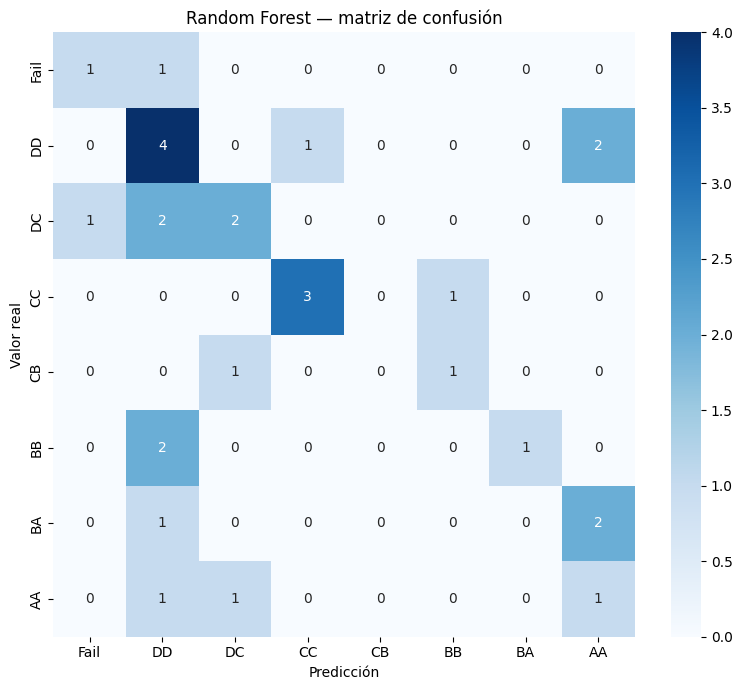

,grade,label,support,precision,recall,f1,false_negatives,false_positives
0,0,Fail,2,0.5000,0.5000,0.5000,1,1
1,1,DD,7,0.3636,0.5714,0.4444,3,7
2,2,DC,5,0.5000,0.4000,0.4444,3,2
3,3,CC,4,0.7500,0.7500,0.7500,1,1
4,4,CB,2,0.0000,0.0000,0.0000,2,0
5,5,BB,3,0.0000,0.0000,0.0000,3,2
6,6,BA,3,0.0000,0.0000,0.0000,3,1
7,7,AA,3,0.2000,0.3333,0.2500,2,4


In [18]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[GRADE_LABELS[i] for i in range(8)],
    yticklabels=[GRADE_LABELS[i] for i in range(8)],
    ax=ax,
)
ax.set_title("Random Forest — matriz de confusión")
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")
fig.tight_layout()
fig.savefig(FIG_DIR / "rf_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

display(
    rf_per_class[
        [
            "grade",
            "label",
            "support",
            "precision",
            "recall",
            "f1",
            "false_negatives",
            "false_positives",
        ]
    ].round(4)
)

## 14. Interpretabilidad — feature importance agregada

El notebook original imprimía el vector de importancias sin nombres, lo que impedía interpretar el resultado. Aquí se recupera la metadata del vector ensamblado y se agregan las importancias de las dummies al nombre de la variable original.

,feature,importance
8,father_occup,0.072712
11,grade_previous,0.057934
0,accomodation,0.050154
9,flip_classrom,0.045130
1,activity,0.040455
24,sex,0.040055
12,graduated_h_school_type,0.038884
25,siblings,0.038666
23,scholarship_type,0.038662
18,partner,0.036443


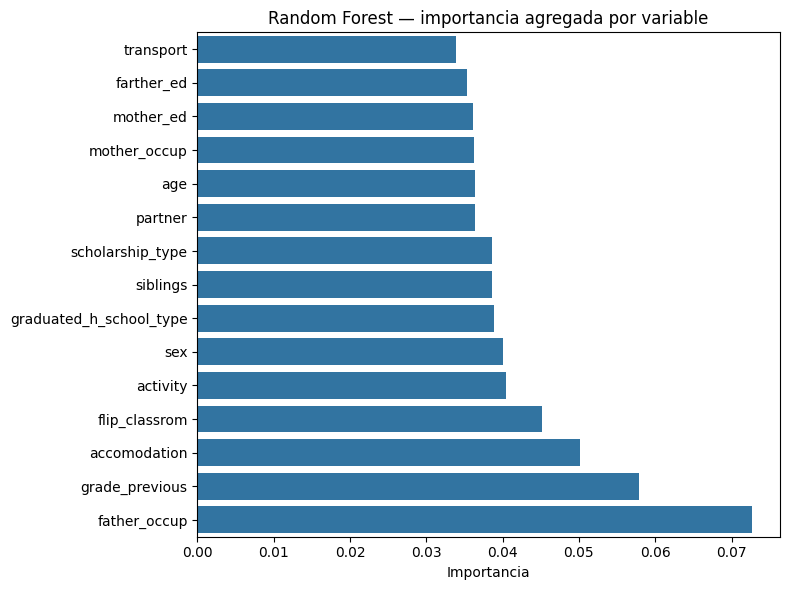

In [19]:
def feature_names_from_metadata(transformed_df, features_col="features"):
    metadata = transformed_df.schema[features_col].metadata
    ml_attr = metadata.get("ml_attr", {})
    num_attrs = ml_attr.get("num_attrs", 0)

    names = [None] * num_attrs

    for attr_group in ml_attr.get("attrs", {}).values():
        for attr in attr_group:
            idx = attr["idx"]
            names[idx] = attr.get("name", f"feature_{idx}")

    return [
        name if name is not None else f"feature_{i}"
        for i, name in enumerate(names)
    ]


feature_names = feature_names_from_metadata(rf_preds, "features")
importance_values = np.array(best_rf_stage.featureImportances.toArray())

assert len(feature_names) == len(importance_values)

encoded_importance = pd.DataFrame({
    "encoded_feature": feature_names,
    "importance": importance_values,
})

def to_original_feature(name):
    for c in NOMINAL_COLS:
        if name.startswith(f"{c}_ohe"):
            return c
    return name

encoded_importance["feature"] = encoded_importance["encoded_feature"].map(to_original_feature)

feature_importance = (
    encoded_importance
    .groupby("feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

display(feature_importance.head(15))

fig, ax = plt.subplots(figsize=(8, 6))
top_imp = feature_importance.head(15).sort_values("importance")
sns.barplot(data=top_imp, x="importance", y="feature", ax=ax)
ax.set_title("Random Forest — importancia agregada por variable")
ax.set_xlabel("Importancia")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIG_DIR / "rf_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

## 15. Lectura crítica de resultados

La lectura final debe considerar simultáneamente:

1. **Generalización:** el conjunto tiene solo 145 filas, por lo que las métricas tienen alta incertidumbre.
2. **Desbalance:** las ocho clases no tienen el mismo soporte; por eso Macro F1 y métricas por clase complementan Accuracy.
3. **Ordinalidad:** confundir categorías cercanas no tiene el mismo significado que errar por varias categorías. `ordinal_mae` y `within_1` capturan esa distancia.
4. **Course ID:** se excluye del modelo principal por riesgo de dependencia de curso. En un despliegue real convendría validación agrupada por curso/institución.
5. **Escalabilidad:** este dataset es demasiado pequeño para demostrar mejoras de rendimiento distribuido. El valor del ejercicio está en usar operaciones y pipelines que pueden escalar a fuentes mayores.
6. **Interpretabilidad:** feature importance describe uso predictivo del modelo, no causalidad.

In [20]:
best_model_name = (
    "Random Forest tuned"
    if rf_metrics["weighted_f1"] >= lr_metrics["weighted_f1"]
    else "Logistic Regression"
)

best_metrics = rf_metrics if best_model_name == "Random Forest tuned" else lr_metrics

print("Resumen ejecutivo")
print("-----------------")
print("Modelo con mejor Weighted F1 en test:", best_model_name)
print(f"Accuracy:      {best_metrics['accuracy']:.4f}")
print(f"Weighted F1:   {best_metrics['weighted_f1']:.4f}")
print(f"Macro F1:      {best_metrics['macro_f1']:.4f}")
print(f"Ordinal MAE:   {best_metrics['ordinal_mae']:.4f}")
print(f"Within ±1:     {best_metrics['within_1']:.4f}")
print(f"Within ±2:     {best_metrics['within_2']:.4f}")

Resumen ejecutivo
-----------------
Modelo con mejor Weighted F1 en test: Random Forest tuned
Accuracy:      0.3793
Weighted F1:   0.3477
Macro F1:      0.2986
Ordinal MAE:   1.7586
Within ±1:     0.6207
Within ±2:     0.7586


## 16. Conclusiones

La versión profesionalizada del proyecto cambia el foco desde “usar Spark para entrenar un modelo” hacia un flujo completo de **calidad de datos, formulación correcta del target, preprocesamiento reproducible, validación, tuning, evaluación multiclase e interpretación**.

La principal mejora metodológica respecto del notebook original es tratar `grade` como una **clase categórica ordinal**, en línea con la fuente UCI y con la rúbrica que exige matriz de confusión y análisis de falsos positivos/negativos.

Como siguientes pasos:

- validación agrupada por curso e institución;
- más observaciones y validación temporal;
- análisis de estabilidad de categorías;
- comparación con modelos ordinales específicos;
- monitoreo de drift y calidad si el pipeline se operacionaliza;
- pruebas de escalabilidad sobre un volumen realmente masivo.

## 17. Cierre de Spark

In [21]:
train_df.unpersist()
test_df.unpersist()
df.unpersist()
spark.stop()